### Introduction to the real-world problem

---

*Dataset description*

El dataset seleccionado para este proyecto es *Breast Cancer Wisconsin (Diagnostic)* (Mangasarian, 1993), recuperado del [UC Irvine Machine Learning Repository](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic). Este conjunto de datos se enfoca en el área médica, en la investigación para el diagnóstico del cáncer de mama.

Su propósito principal es clasificar tumores como benignos o malignos a partir de características obtenidas de imágenes digitalizadas de aspiraciones con aguja fina (FNA) de masas mamarias.

El dataset tiene un total de 569 datos y 32 columnas. De estas, una corresponde al número de cada muestra (ID) y la otra es la variable objetivo (Diagnosis), donde M indica un tumor maligno y B uno benigno. Las 30 variables restantes corresponden a características numéricas calculadas a partir de las imágenes.

Para cada núcleo celular se calcularon 10 características principales, y de cada una se obtuvieron tres medidas diferentes: promedio, error estándar y valor máximo. Esto nos da, al final del día, 30 variables predictoras.


Las 10 características principales son:

- radius: media de las distancias desde el centro hasta los puntos del perímetro.

- texture: desviación estándar de los valores en escala de grises.

- perimeter: longitud del contorno del núcleo.

- area: área del núcleo.

- smoothness: variación local en las longitudes del radio.

- compactness: $$
\frac{\text{perimeter}^2}{\text{area}} - 1
$$
- concavity: severidad de las porciones cóncavas del contorno.

- concave points: número de porciones cóncavas del contorno.

- symmetry: simetría del núcleo.

- fractal dimension: $$\text{coastline approximation} - 1$$


*Data cleaning*

Previo a comenzar con la arquitectura del modelo, fue necesario que realizáramos la limpieza del dataset.

En primer lugar, se cargó el archivo del dataset en formato de `.csv` con ayuda de la función `pd.read_csv()`. Además, para asegurar la reproducibilidad de los resultados, decidimos implementar una semilla aleatoria `(SEED = 42)`. Esto nos permite que los procesos que incluyen aleatoriedad dentro del código generen siempre los mismos valores cada vez que se ejecute el código, lo que nos permite ser consistentes a la hora de trabajar en el proyecto. Posteriormente, se asignaron manualmente los nombres de las variables de acuerdo con la estructura publicada en el sitio web del repositorio.


Una vez cargados y nombrados los datos, se procedió con la limpieza:

**Eliminación de la columna ID:**

La columna correspondiente al ID fue eliminada, ya que este valor no aporta información relevante para el entrenamiento del modelo.

**Binarización de la variable objetivo:**

La variable Diagnosis originalmente tenía valores categóricos:

- M (maligno)
- B (benigno)

Como el modelo trabaja mejor con valores numéricos, se convirtió esta variable a formato binario, asignando:

- 1 → maligno
- 0 → benigno

**Verificación de valores faltantes:**

Se realizó una revisión de datos faltantes por columna utilizando ```df.isnull().sum()```. Como el resultado indicó que el dataset se encuentra completo no se realizó ningún ajuste.

Después, se revisaron las dimensiones del dataset utilizando ```df.shape```, esto nos sirvió para confirmar que se tenían 569 registros y 31 columnas en total (30 variables predictoras y 1 variable objetivo). Finalmente, se imprimieron las primeras filas con ```df.head()``` para asegurarse de que los cambios realizados durante la limpieza se aplicaron correctamente.

In [ ]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import tensorflow as tf

# Le añadimos una semilla para la reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


df = pd.read_csv('wdbc.csv', header=None)


# Nombrar columnas
column_names = [
    'ID',
    'Diagnosis',
    'radius1','texture1','perimeter1','area1', 'smoothness1',
    'compactness1','concavity1','concave_points1','symmetry1','fractal_dimension1',
    'radius2','texture2','perimeter2','area2', 'smoothness2',
    'compactness2','concavity2','concave_points2','symmetry2','fractal_dimension2',
    'radius3','texture3','perimeter3','area3', 'smoothness3',
    'compactness3','concavity3','concave_points3','symmetry3','fractal_dimension3',
]
df.columns = column_names

# Eliminar la columna ID
df = df.drop('ID', axis=1)

# Diagnosis: B = 0, M = 1
df['Diagnosis'] = np.where(df['Diagnosis'] == 'B', 0, 1)

# Verificar datos faltantes
print("Datos faltantes por columna:")
display(df.isnull().sum())

# Verificar las dimensiones del dataset
print("\nDimensiones del dataset (filas, columnas):")
print(df.shape)

# Verificar estado del dataset
print("\nHead del dataset:")
display(df.head())

Datos faltantes por columna:


,0
Diagnosis,0
radius1,0
texture1,0
perimeter1,0
area1,0
smoothness1,0
compactness1,0
concavity1,0
concave_points1,0
symmetry1,0



Dimensiones del dataset (filas, columnas):
(569, 31)

Head del dataset:


,Diagnosis,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,radius2,texture2,perimeter2,area2,smoothness2,compactness2,concavity2,concave_points2,symmetry2,fractal_dimension2,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


*Exploratory Data Analysis*

Para realizar un análisis exploratorio de los datos, optamos por desarrollar tres análisis principales: las estadísticas descriptivas de las variables, la distribución de la variable objetivo y las correlaciones de las variables.

Primeramente, se agregó la función ```pd.set_option('display.max_columns', None)``` que nos permite evitar que algunas columnas se oculten en la visualización, facilitando el análisis de la información.

**Estadísticas Descriptivas**

Para obtener diversos valores estadísticos de cada una de las variables, se utilizó la función `df.describe()`, la cual permite nos da métricas como la media, valores mínimos, máximos, desviación estándar, etc.

Dentro del contexto de la base de datos, se puede notar que algunas variables relacionadas con la geometría de los tumores presentan una alta dispersión en sus datos. Tomando como ejemplo radius1, perimeter1 y area1, las cuales se relacionan con el promedio obtenido de las mediciones, se observa que radius1 tiene un promedio de 14.13, con valores que varían desde 6.98 hasta 28.11, lo que refleja una amplia variabilidad en el tamaño de los núcleos celulares. De forma similar, el área promedio es de 654.89, pero alcanza valores máximos de 2501, lo cual muestra que existe una gran diversidad en las muestras utilizadas dentro del dataset.

Además, sabiendo que el sufijo 3 se refiere al *worst* de cada una de las características, estas variables suelen presentar valores mayores, ya que corresponden a las mediciones más extremas obtenidas en el estudio.

A partir de este análisis se puede concluir que la alta variabilidad de los datos, junto con la inclusión de valores extremos, proporciona información relevante para el desarrollo de modelos, ya que estas diferencias en las características pueden ayudar a distinguir de mejor manera la diferencia entre tumores benignos y malignos.


**Distribución de la Variable Objetivo**

Para visualizar la distribución de la variable objetivo, realizamos un histograma con ayuda de la función `plt.hist(df['Diagnosis'])`. Además, se utilizaron diversas funciones para darle formato a la gráfica, agregando etiquetas en los ejes y un título, con el fin de que la información se pueda interpretar de manera clara.

Como se puede observar en los resultados, y tomando en cuenta lo obtenido de las estadísticas de la variable Diagnosis en el punto anterior, se puede decir que aproximadamente el 63% de las muestras son benignas y el 37% son malignas. Si bien, esta no es la distribución más balanceada para realizar un modelo (influiría en el entrenamiento y en la interpretación de sus métricas de desempeño.), tampoco representa un desbalance excesivo, por lo que podremos trabajar de manera adecuada con este dataset para tareas de clasificación.

**Correlaciones de las Variables**

Con el fin de analizar qué tan relacionadas se encuentran las características del dataset, se generó una matriz de correlación a partir de la función `corr_matrix = df.corr()`. Posteriormente, con ayuda de `sns.heatmap(corr_matrix, cmap='coolwarm') `se visualizó esta matriz, donde los colores rojos representan valores altos de correlación, mientras que los colores azules indican valores bajos de correlación.

Siguiendo la lógica del dataset, podemos observar que en la matriz de correlación que existen diversas secciones en rojo que relacionan parámetros como área, perímetro y radio entre diferentes grupos de mediciones, por ejemplo area3 y radius1. Esto tiene una lógica teórica, ya que matemáticamente estas variables presentan una dependencia entre sí; sin embargo, también podría indicar una posible redundancia en la información al momento de entrenar un modelo.

Por otro lado, algunas variables como fractal_dimension o symmetry muestran correlaciones más bajas con otras características y altas con Diagnosis, lo que sugiere que estas métricas describen aspectos más independientes de las imágenes.

Estadísticas:
        Diagnosis     radius1    texture1  perimeter1        area1  \
count  569.000000  569.000000  569.000000  569.000000   569.000000   
mean     0.372583   14.127292   19.289649   91.969033   654.889104   
std      0.483918    3.524049    4.301036   24.298981   351.914129   
min      0.000000    6.981000    9.710000   43.790000   143.500000   
25%      0.000000   11.700000   16.170000   75.170000   420.300000   
50%      0.000000   13.370000   18.840000   86.240000   551.100000   
75%      1.000000   15.780000   21.800000  104.100000   782.700000   
max      1.000000   28.110000   39.280000  188.500000  2501.000000   

       smoothness1  compactness1  concavity1  concave_points1   symmetry1  \
count   569.000000    569.000000  569.000000       569.000000  569.000000   
mean      0.096360      0.104341    0.088799         0.048919    0.181162   
std       0.014064      0.052813    0.079720         0.038803    0.027414   
min       0.052630      0.019380    0.000000   

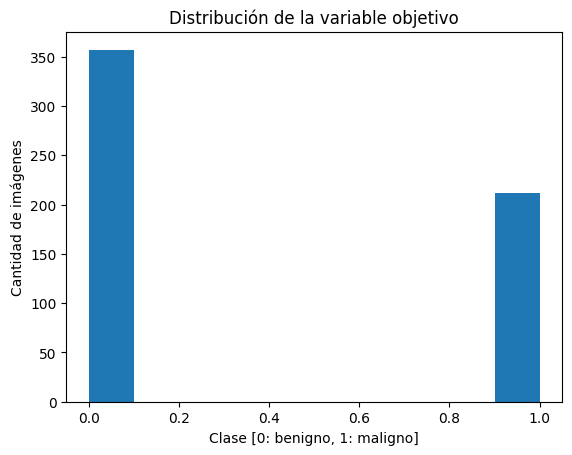

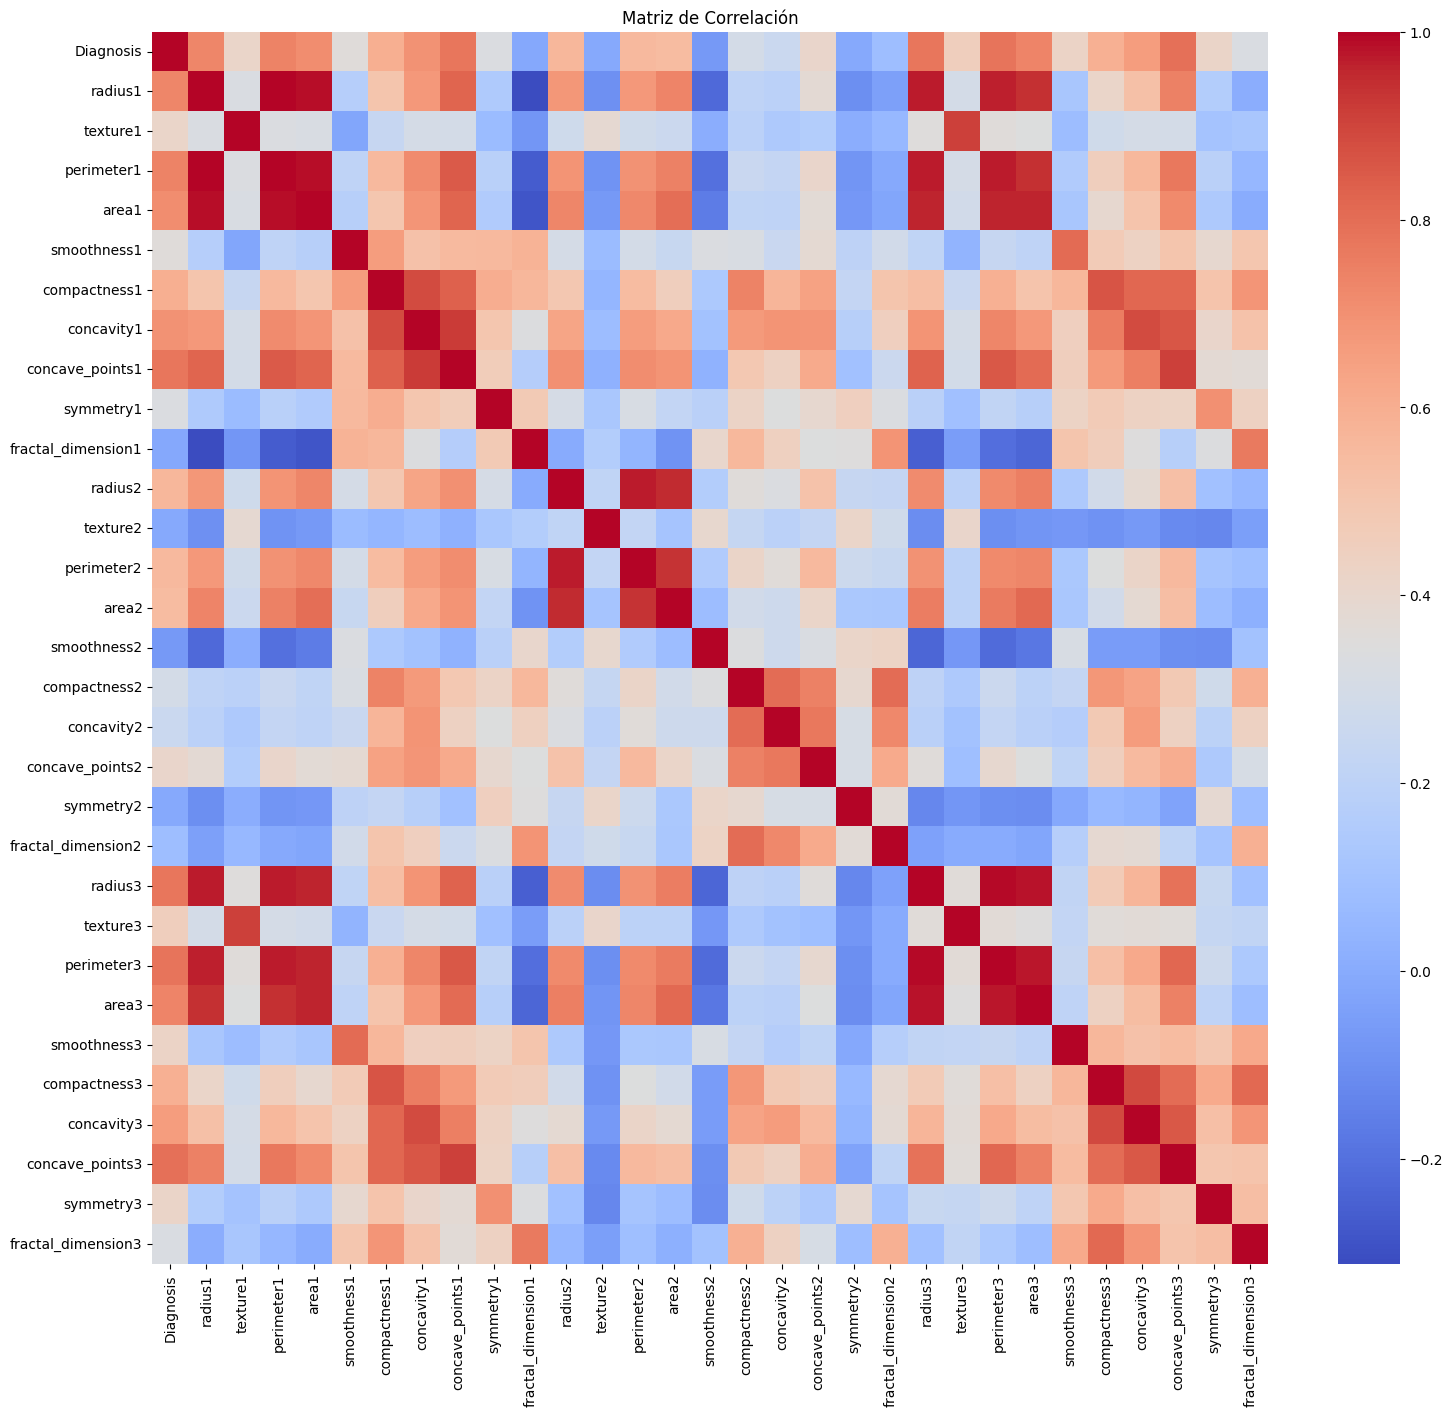

In [ ]:
pd.set_option('display.max_columns', None)

# Estadísticas de las variables
print("Estadísticas:")
print(df.describe())

# Revisar distribución de variable objetivo (Diagnosis)
plt.figure()
plt.hist(df['Diagnosis']);
plt.xlabel('Clase [0: benigno, 1: maligno]')
plt.ylabel('Cantidad de imágenes')
plt.title('Distribución de la variable objetivo')
plt.show()

# Calcular la matriz de correlación
corr_matrix = df.corr()
plt.figure(figsize=(18,16))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()


### Design and Training of the Single-Neuron Model

---
Antes de comenzar con el diseño del modelo, es primordial comprender qué es el modelo de neurona simple. De acuerdo con lo visto en clase, este representa la arquitectura más básica dentro de las redes neuronales y funciona como un bloque de construcción indispensable para modelos de aprendizaje más profundos y complejos.

Su principal objetivo es actuar como una unidad de procesamiento en la que se reciben entradas, se les aplican los pesos correspondientes, se suma un término de sesgo y al final el resultado se pasa a través de una función de activación para finalmente producir una salida (GeeksforGeeks, 2025).

Pasos para poder construir el modelo:

**train/validation/test split**

Para preparar los datos antes del entrenamiento del modelo, primero tenemos que separar las características del dataset (X) y la variable objetivo (y). En este caso, X contiene las 30 características relacionadas con las propiedades de los tumores, mientras que Y corresponde a la variable Diagnosis. Para esto se utilizó la función `df.drop()` para guardar las 30 características de X y Diagnosis se guardó como y.

Después de ello, el dataset se dividió en tres subconjuntos: entrenamiento (train), validación (validation) y prueba (test). Para realizar esta división se utilizó dos veces la función `train_test_split`. Primero, se asignó el 20% de los datos al conjunto de prueba, mientras que el 80% restante se dividió nuevamente en 75% para entrenamiento y 25% para validación. Esto resulta en una distribución aproximada de 60% entrenamiento, 20% validación y 20% prueba.

Además, utilizamos el parámetro stratify para asegurar que la proporción de clases (benigno y maligno) se mantenga similar en todos los subconjuntos, evitando sesgos en la distribución de los datos. También se definió random_state=42 para garantizar que la división sea reproducible.

**Feature Standardization**

A partir de lo analizado en las estadísticas descriptivas, pudimos observar que las variables presentan diferentes rangos y desviaciones estándar. Esto indica que las características no se encuentran en la misma escala, por lo que es necesario aplicar un proceso de estandarización antes de entrenar el modelo. La estandarización permite que todas las variables tengan una media cercana a 0 y una desviación estándar cercana a 1, lo cual ayuda a mejorar el desempeño de los modelos de aprendizaje.

Para ello, se utilizó `StandardScaler`, el cual permite transformar los datos para lograr lo anterior, es decir, tener medias cercanas a 0 y desviaciones estándar cercanas a 1. Siguiendo la buena práctica de prevención de data leakage, el escalador fue ajustado (fit) únicamente con los datos de entrenamiento (`X_train`). Posteriormente, la transformación aprendida fue aplicada a los conjuntos de validación (`X_val`) y prueba (`X_test`).

Finalmente, se verificó que las características del conjunto de entrenamiento estuvieran correctamente estandarizadas, observando que su media sea cercana a 0 y su desviación estándar cercana a 1.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separar características (X) y objetivo (y)
X = df.drop('Diagnosis', axis=1)  # 30 características
y = df['Diagnosis']                # Variable objetivo

# Primera división: 20% para test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Segunda división: dividir el 80% restante en 75% train y 25% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print("Tamaños de los conjuntos:")
print(f"Training set: {X_train.shape[0]} muestras ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} muestras ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} muestras ({X_test.shape[0]/len(X)*100:.1f}%)")

# Estandarizar features usando StandardScaler
scaler = StandardScaler()

# Fit scaler solo con training data y transformar todos los conjuntos
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures estandarizados exitosamente")
print(f"Media de features (train): {X_train_scaled.mean(axis=0).round(4)}")
print(f"Desviación estándar (train): {X_train_scaled.std(axis=0).round(4)}")

print(y_train.value_counts(normalize=True))

Tamaños de los conjuntos:
Training set: 341 muestras (59.9%)
Validation set: 114 muestras (20.0%)
Test set: 114 muestras (20.0%)

Features estandarizados exitosamente
Media de features (train): [ 0. -0.  0. -0.  0. -0.  0.  0.  0.  0.  0. -0. -0. -0. -0. -0.  0. -0.
 -0. -0. -0. -0.  0.  0. -0.  0. -0.  0. -0.  0.]
Desviación estándar (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]
Diagnosis
0    0.627566
1    0.372434
Name: proportion, dtype: float64


**Arquitectura del Modelo**

Para poder desarrollar el modelo, utilizamos `TensorFlow`, construyendo una arquitectura simple de una sola neurona. Esta se define con el parámetro `Dense` con una única neurona `(units=1)`. Esta neurona recibe como entrada las 30 características del dataset, correspondientes a las variables obtenidas del núcleo celular.

En cuanto a la función de activación, se utilizó la activación sigmoide, por medio del parámetro `sigmoid`, la cual, según lo que aprendimos en clase, transforma la salida del modelo en valores entre 0 y 1; es decir, en la probabilidad de que un tumor sea maligno. Esta función de activación es muy común en problemas de clasificación binaria, ya que nos permite interpretar directamente la salida como la probabilidad de que un dato pertenezca a una de las dos clases.

**Loss Function**

Para el modelo se utilizó la función de pérdida `binary_crossentropy`, la cual, como vimos en clase, es la más adecuada para problemas de clasificación binaria, ya que mide qué tan bien las predicciones del modelo coinciden con las etiquetas reales.

**Optimiser**

En cuanto al optimizador utilizado, según lo recomendado en las instrucciones se utilizó el optimizador `Adam`. Este es muy utilizado en el entrenamiento de redes neuronales, ya que permite ajustar automáticamente la tasa de aprendizaje (learning rate) durante el entrenamiento.

Para el optimizador, establecimos un learning rate de 0.001, el cual determina qué tan grandes son los pasos que da el optimizador al momento de ajustar los pesos.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Definir hiperparámetros
LEARNING_RATE = 0.001
print(f"Learning rate: {LEARNING_RATE}")

# Construimos el modelo con una única neurona
model = keras.Sequential([
    layers.Dense(
        units=1,                    # Una sola neurona
        activation='sigmoid',       # Activación sigmoid para clasificación binaria
        input_shape=(30,)          # 30 features de entrada
    )
])

# Compilar el modelo
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',    # Pérdida para problemas binarios
    metrics=['accuracy']           # Métrica de evaluación
)

# Mostrar arquitectura del modelo
print("Arquitectura del modelo:")
model.summary()


Learning rate: 0.001


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Arquitectura del modelo:


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

*Model Training*

Para entrenar el modelo utilizamos la función `model.fit()`. Esta función se encarga de ajustar los pesos de la red neuronal utilizando los datos de entrenamiento (X_train_scaled, y_train) y los datos de validación (X_val_scaled, y_val) junto con los hiperparámetros.

**Hyperparameters**

Para el entrenamiento del modelo se definieron algunos hiperparámetros que controlan el proceso de aprendizaje de la red neuronal.

Primero, definimos el número de epochs en 50, lo que significa que el modelo recorrerá el conjunto de datos de entrenamiento completo 50 veces. Esto permite que la red neuronal tenga múltiples oportunidades de ajustar sus pesos y mejorar su desempeño sin caer en un sobreajuste de los datos.

El batch size se estableció en 32, lo que indica que los datos de entrenamiento se procesan en grupos de 32 muestras a la vez antes de actualizar los pesos del modelo.

Se utilizó el parámetro `validation_data=(X_val_scaled, y_val)` para proporcionar explícitamente el conjunto de validación separado que fue creado anteriormente. Esto permite monitorear el desempeño del modelo en datos que no fueron utilizados durante el entrenamiento.

Finalmente, durante el entrenamiento se utilizó el parámetro `verbose=1`, lo cual nos permite visualizar en la consola el progreso del entrenamiento en cada epoch.

In [ ]:
# Definir hiperparámetros
EPOCHS = 50
BATCH_SIZE = 32

# Mostrar hiperparámetros
print("Hiperparámetros:")
print(f"Epochs: {EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Validación: usando conjunto de validación separado")

# Entrenar el modelo
history = model.fit(
    X_train_scaled, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_scaled, y_val),
    verbose=1
)

Hiperparámetros:
Epochs: 50
Batch size: 32
Validación: usando conjunto de validación separado
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - accuracy: 0.5676 - loss: 0.6821 - val_accuracy: 0.6053 - val_loss: 0.6625
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6552 - loss: 0.6090 - val_accuracy: 0.7018 - val_loss: 0.5978
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7722 - loss: 0.5454 - val_accuracy: 0.7719 - val_loss: 0.5422
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8233 - loss: 0.4914 - val_accuracy: 0.8070 - val_loss: 0.4950
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8688 - loss: 0.4459 - val_accuracy: 0.8421 - val_loss: 0.4550
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9032 - loss: 0.4078 - val_accuracy: 0.8684 - val_loss: 0.4211
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9334 - loss: 0.3759 - val_accuracy: 0.8772 - val_loss: 0.3923
Epoch 8/50
11/11

### Learning Curve Anslysis

---
Para analizar el desempeño del modelo durante el entrenamiento, se generaron dos gráficas que permiten observar cómo evoluciona el accuracy y la función de pérdida (loss) a lo largo de las épocas. En la primera gráfica se muestra el accuracy del modelo, utilizando `plt.plot(history.history['accuracy'])`para el conjunto de entrenamiento y `plt.plot(history.history['val_accuracy'])` para el conjunto de validación. Posteriormente, se generó la gráfica de loss, utilizando `plt.plot(history.history['loss'])` y `plt.plot(history.history['val_loss'])`.

Una vez generadas las gráficas, podemos analizar si el modelo presenta sobreajuste, falta de ajuste o si está correctamente ajustado. Como se puede observar en la gráfica de accuracy, la línea de validación (naranja) sigue de manera bastante similar a la línea azul que representa el entrenamiento. El hecho de que ambas tengan un comportamiento parecido nos indica que el modelo no está sobreajustado. Además, ambas curvas se aproximan a un valor cercano al 97% de accuracy, lo cual también sugiere que el modelo está aprendiendo correctamente y no presenta un problema de falta de ajuste.

Por otro lado, en la gráfica de loss podemos observar que hacia el final de las épocas existe una pequeña diferencia entre el error del conjunto de entrenamiento y el de validación. Sin embargo, esta diferencia no es demasiado grande como para indicar sobreajuste, y el valor de error en ambos casos es relativamente bajo. Por lo tanto, podemos concluir que, en general, el modelo se encuentra **ajustado de manera adecuada** para los datos utilizados.

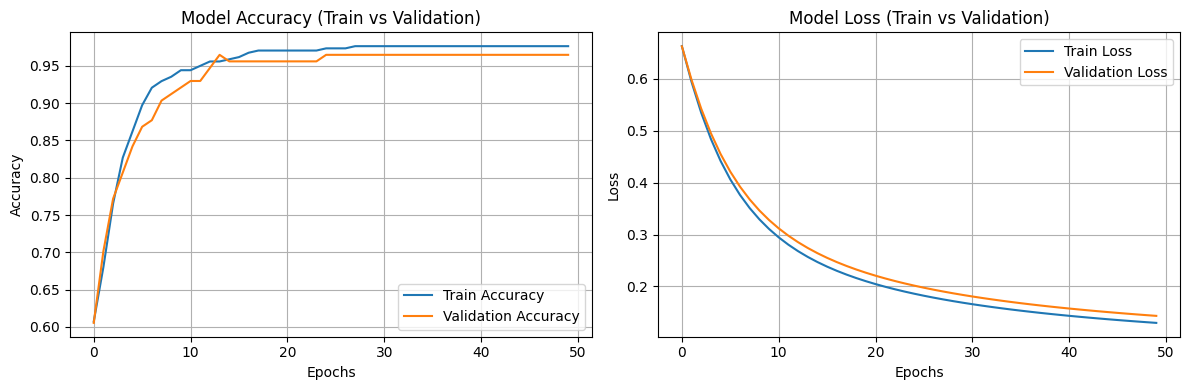

In [ ]:
# Gráfico de Accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy (Train vs Validation)')
plt.legend()
plt.grid()

# Gráfico de Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss (Train vs Validation)')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


### Model Evaluation and Testing Data


---

Ya teniendo entrenado el modelo y después de verificar que tuviera un ajuste correcto, se realizó su evaluación utilizando el conjunto de datos de prueba (test set). Esto permite medir qué tan bien generaliza el modelo con datos que no fueron utilizados durante el entrenamiento.

Primeramente, con ayuda de la función `model.predict()` se generaron las predicciones del modelo, ya que esta función nos entrega las probabilidades de que cada muestra sea considerada como maligna.

Posteriormente, con `y_pred = (y_pred_prob > 0.5).astype(int).flatten()` se creó un threshold de 0.5, donde:

- Si la probabilidad es mayor a 0.5, el modelo predice malignant (1).
- Si la probabilidad es menor o igual a 0.5, el modelo predice benign (0).


Ya con las predicciones binarizadas pasamos al cálculo de las métricas de evaluación. Comenzamos con el accuracy del conjunto de prueba, el cual se obtuvo con la función `accuracy_score(y_test, y_pred)`. El accuracy representa la proporción de predicciones correctas respecto al total de predicciones realizadas. En este caso, el modelo obtuvo un valor de 0.9737, lo cual significa que aproximadamente el 97.37% de las predicciones fueron correctas.

Posteriormente se calculó la matriz de confusión a partir de la función `confusion_matrix(y_test, y_pred)`. En este caso se obtuvieron los siguientes valores:

- True Negatives (TN): casos benignos correctamente identificados. El modelo obtuvo 71.
- True Positives (TP): casos malignos correctamente identificados. El modelo obtuvo 40.
- False Positives (FP): casos benignos que el modelo clasificó incorrectamente como malignos. El modelo obtuvo 1.
- False Negatives (FN): casos malignos que el modelo clasificó incorrectamente como benignos. El modelo obtuvo 2.


La precisión se calculó utilizando `precision_score(y_test, y_pred)`. Esta métrica indica qué proporción de las muestras que el modelo predijo como malignas realmente lo eran. En otras palabras, mide qué tan confiables son las predicciones positivas del modelo. El modelo obtuvo 0.9750.

El recall se obtuvo con `recall_score(y_test, y_pred)`. Esta métrica mide qué tan bien el modelo es capaz de detectar los casos malignos reales, es decir, qué proporción de los tumores malignos fueron correctamente identificados por el modelo. El modelo obtuvo 0.9286.

También se calculó la specificity, utilizando la fórmula `tn / (tn + fp)`. Esta métrica indica qué tan bien el modelo identifica correctamente los casos benignos, evitando clasificarlos como malignos. El modelo obtuvo 0.9861.

Finalmente, se calculó el F1-score utilizando `f1_score(y_test, y_pred)`. Esta métrica combina la precisión y el recall en un solo valor, proporcionando una medida del desempeño del modelo. El modelo obtuvo 0.9512.

Tomando en cuenta el contexto del dataset, el cual busca clasificar tumores benignos y malignos a partir de características del núcleo celular, es importante analizar métricas que reflejen no solo la precisión general del modelo, sino también su capacidad para detectar correctamente los casos malignos ya que, en un entorno clínico, el predecir un tumor como benigno cuando en realidad era maligno sería un problema grave.

A partir de la matriz de confusión obtenida, se observa que el modelo logró 71 verdaderos negativos (tumores benignos correctamente clasificados) y 39 verdaderos positivos (tumores malignos correctamente identificados). Asimismo, se presentaron 1 falso positivo, es decir, un caso benigno que fue clasificado como maligno, y 3 falsos negativos, correspondientes a tumores malignos que el modelo clasificó como benignos. Con esto podemos decir que si bien, el modelo comete errores de clasificación, son contados los casos en los que sucede.

En términos de métricas de evaluación, el modelo obtuvo un accuracy de aproximadamente 96.49%, lo que indica que la gran mayoría de las predicciones realizadas fueron correctas. Sin embargo, en problemas médicos es particularmente importante observar métricas como recall, ya que esta mide la capacidad del modelo para detectar los casos malignos. En este caso, el recall es cercano a 92.86%, lo que significa que el modelo logra identificar la mayoría de los tumores malignos presentes en el conjunto de prueba.

En general, estos resultados son buenos; sin embargo, en un ambiente clínico probablemente sería necesario trabajar diferentes arquitecturas que den resultados más certeros.

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Test Accuracy: 0.9737

Confusion Matrix:
[[71  1]
 [ 2 40]]

Precision: 0.9756
Recall (Sensitivity): 0.9524
Specificity: 0.9861
F1-Score: 0.9639


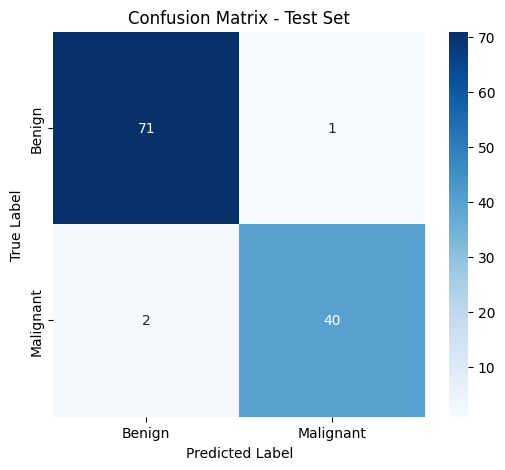

In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import seaborn as sns

# Realizar predicciones en test set
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Calcular accuracy en test
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Calcular métricas
tn, fp, fn, tp = cm.ravel()

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
specificity = tn / (tn + fp)
f1 = f1_score(y_test, y_pred)

print(f"\nPrecision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score: {f1:.4f}")

# Visualizar Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


### Save the Model


---

Ya que hemos completado el entrenamiento y el test del modelo, ahora guardamos la arquitectura y los pesos entrenados en un archivo. Esto nos ayuda a reutilizar el modelo entrenado para poder realizar predicciones futuras sin tener que volver a entrenarlo desde cero.

Para guardar el modelo utilizamos `model.save()` de Keras. Este lo que hace es guardar la arquitectura de la red neuronal, además de los valores de los pesos y sesgos que se obtuvieron al entrenar. Después, para verificar que el modelo se guardó exitosamente y que funciona se carga el modelo con `keras.models.load_model()`.

In [ ]:
# Guardar el modelo original
model.save('single_neuron_model.keras')

# Cargar el modelo para verificar
loaded_model = keras.models.load_model('single_neuron_model.keras')

# Verificar que el modelo cargado funciona correctamente
test_pred = loaded_model.predict(X_test_scaled[:5])
print("\nPrimeras 5 predicciones del modelo original cargado:")
print(test_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step

Primeras 5 predicciones del modelo original cargado:
[[0.02423122]
 [0.9990261 ]
 [0.315279  ]
 [0.5822758 ]
 [0.40032974]]


### Principal Component Analysis (PCA) Extension


---

**Introducción a PCA**

Para reducir la dimensionalidad del dataset se utilizó Principal Component Analysis (PCA), para ello utilizamos la librería scikit-learn. En este caso, configuramos el parámetro `n_components=0.95`, esto hace que el algoritmo seleccione automáticamente el número mínimo de componentes principales para explicar al menos el 95% de la varianza total de los datos.

**Proceso de Aplicación de PCA**

El modelo de PCA fue entrenado con el conjunto de entrenamiento escalado (`X_train_scaled`). Después de ello, la transformación obtenida fue aplicada también a los conjuntos de validación y prueba para mantener consistencia.

**Resultados de la Reducción de Dimensionalidad**

Como resultado del análisis, se obtuvo que 10 componentes principales son suficientes para explicar aproximadamente el 95.37% de la varianza total del dataset. Esto significa que la mayor parte de la información en las 30 variables originales puede se puede representar utilizando únicamente 10 nuevas variables transformadas y al hacerlo se obtiene una reducción de dimensionalidad del 66.7%.

**Interpretación de la Varianza Explicada**

En el primer gráfico, titulado "Explained Variance per Component", se muestra cuánta varianza de los datos es explicada por cada componente principal de manera individual. El primer componente principal explica aproximadamente el 45% de la varianza, mientras que los siguientes componentes explican porcentajes progresivamente menores. Los primeros componentes contienen la mayor parte de la información relevante del dataset, y los que le siguen contienen información cada vez menor, esto es de gran ayuda para identificar qué componentes son verdaderamente importantes.

**Varianza Explicada Acumulada**

En el segundo gráfico, "Cumulative Explained Variance", se muestra la varianza acumulada conforme se agregan más componentes principales. La línea roja punteada representa el umbral del 95% de varianza explicada, el cual fue establecido como criterio y meta para seleccionar el número de componentes.

La curva alcanza este umbral aproximadamente en el componente número 10, lo que confirma que con 10 componentes es posible representar la mayor parte de la información presente en los datos originales de forma más eficiente.

Número de componentes PCA (95% varianza): 10
Varianza explicada total: 0.9537
Reducción de dimensionalidad: 30 → 10 features (66.7% reducción)


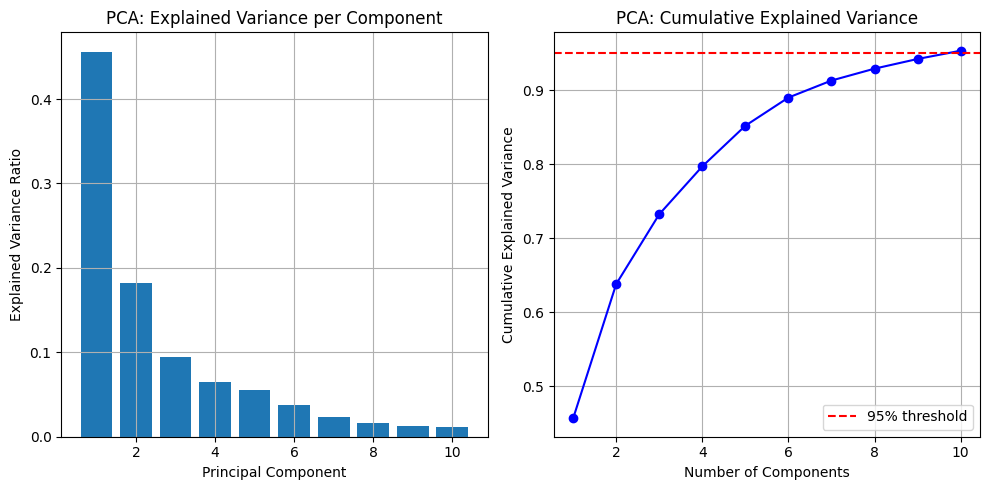

In [ ]:
from sklearn.decomposition import PCA

# Aplicar PCA con 95% de varianza explicada
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

n_components = pca.n_components_
explained_variance = pca.explained_variance_ratio_.sum()

print(f"Número de componentes PCA (95% varianza): {n_components}")
print(f"Varianza explicada total: {explained_variance:.4f}")
print(f"Reducción de dimensionalidad: {30} → {n_components} features ({(1 - n_components/30)*100:.1f}% reducción)")

# Gráfico de varianza explicada
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1),
        pca.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA: Explained Variance per Component')
plt.grid()

plt.subplot(1, 2, 2)
cumsum = np.cumsum(pca.explained_variance_ratio_)
plt.plot(range(1, len(cumsum) + 1), cumsum, 'bo-')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA: Cumulative Explained Variance')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


### Model Construction and Training with PCA Components


---

**Arquitectura del Modelo con PCA**

Para entrenar el modelo utilizando las características transformadas por PCA, construimos una red neuronal simple de una sola neurona. El modelo fue implementado utilizando la API Keras Sequential, la cual permite definir redes neuronales de forma secuencial capa por capa.

En este caso, el modelo lo creamos usando únicamente una capa densa con una neurona que utiliza la función de activación sigmoid, la cual es comúnmente utilizada en problemas de clasificación binaria, ya que produce valores de salida entre 0 y 1 que pueden interpretarse como probabilidades de pertenecer a una clase.

**Características de Entrada y Parámetros**

El modelo recibe como entrada los componentes principales obtenidos mediante PCA, por lo que el número de entradas del modelo es el número de componentes seleccionados previamente. El modelo utiliza 10 componentes principales como variables de entrada, en lugar de las 30 variables originales del dataset.

Gracias a esto, el modelo tiene únicamente 11 parámetros entrenables: 10 pesos correspondientes a cada una de las 10 entradas, más un término de sesgo (bias) adicional. Esto hace que el modelo sea simple y computacionalmente eficiente, ya que solo hay que entrenar una cantidad muy pequeña de parámetros comparado con el modelo original.

**Configuración del Entrenamiento**

Durante el proceso de entrenamiento, entrenamos al modelo durante 50 épocas, utilizando el optimizador Adam con un learning rate de 0.001 y la función de pérdida binary crossentropy, que es lo mejor para problemas de clasificación binaria. Se utilizó un batch size de 32 muestras y se reservó el 20% de los datos de entrenamiento para validación.

En las primeras épocas del entrenamiento, el accuracy es relativamente baja, esto tiene todo el sentido del mundo, ya que el modelo comienza con pesos inicializados aleatoriamente. Sin embargo, conforme avanza el entrenamiento, tanto la accuracy de entrenamiento como la de validación comienzan a aumentar gradualmente.

Al final del entrenamiento, el modelo alcanza una accuracy de validación cercana al 96%, lo que indica que el modelo es capaz de aprender patrones relevantes dentro de los datos transformados por PCA. De manera similar, la función de pérdida disminuye progresivamente a lo largo de las épocas, demostrando que el modelo está mejorando su capacidad para realizar predicciones correctas.

In [ ]:
# Construir modelo con PCA features
model_pca = keras.Sequential([
    layers.Dense(
        units=1,
        activation='sigmoid',
        input_shape=(n_components,)
    )
])

model_pca.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(f"Arquitectura del modelo PCA:")
model_pca.summary()

# Entrenar modelo con PCA
history_pca = model_pca.fit(
    X_train_pca, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_pca, y_val),
    verbose=1
)


Arquitectura del modelo PCA:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11 (44.00 B)

 Trainable params: 11 (44.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8475 - loss: 0.4268 - val_accuracy: 0.8158 - val_loss: 0.3788
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8487 - loss: 0.4153 - val_accuracy: 0.8509 - val_loss: 0.3678
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8556 - loss: 0.4045 - val_accuracy: 0.8596 - val_loss: 0.3572
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8605 - loss: 0.3942 - val_accuracy: 0.8772 - val_loss: 0.3471
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8626 - loss: 0.3843 - val_accuracy: 0.8860 - val_loss: 0.3375
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8715 - loss: 0.3748 - val_accuracy: 0.8947 - val_loss: 0.3282
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8775 - loss: 0.3658 - val_accuracy: 0.8947 - val_loss: 0.3194
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8775 - loss: 0.3571 - val_accuracy: 0.8947 - val_loss

### Analysis of Model Learning Curves with PCA


---

Para evaluar el comportamiento del modelo durante el entrenamiento, graficamos las curvas de accuracy y loss tanto para el conjunto de entrenamiento como para el de validación. Así podemos ver fácilmente si el modelo realmente está aprendiendo y, al mismo tiempo, detectar posibles señales de sobreajuste (overfitting) o subajuste (underfitting).

**Interpretación del Gráfico de Accuracy**

En el gráfico "PCA Model Accuracy (Train vs Validation)" se observa que la accuracy de entrenamiento comienza alrededor de 0.31 y aumenta gradualmente conforme avanzan las épocas. De manera similar, la accuracy de validación sigue una tendencia muy parecida y se mantiene cercana a la curva de entrenamiento durante casi todo el proceso.

Esto es un indicador positivo, ya que el modelo no está memorizando únicamente los datos de entrenamiento, sino que también está generalizando hacia datos que nunca ha visto (los datos de validación). Hacia el final del entrenamiento, ambas curvas se estabilizan aproximadamente alrededor de 0.93-0.94, donde el modelo llega a un punto donde ya no mejora de manera significativa con más épocas.

**Interpretación del Gráfico de Loss**

En el gráfico "PCA Model Loss (Train vs Validation)" se observa que la pérdida comienza alta (cercana a 1.5-1.6) y disminuye constantemente conforme avanzan las épocas. Esto indica que el modelo está reduciendo su error de predicción de forma consistente durante el entrenamiento.

Además, la curva de pérdida de validación se mantiene ligeramente por encima de la de entrenamiento, lo cual es un comportamiento esperado. La diferencia entre ambas curvas es pequeña y se mantiene estable durante todo el proceso. Hacia el final del entrenamiento, la loss se reduce aproximadamente a 0.26 en entrenamiento y cerca de 0.29 en validación, lo que confirma que el modelo logró aprender patrones relevantes en los datos.

**Conclusión: Modelo Bien Ajustado**

En conclusión, el modelo con PCA muestra un ajuste adecuado de los datos. Esto puede observarse gracias a varios factores. Primero, las curvas de entrenamiento y validación siguen trayectorias similares tanto en accuracy como en loss, lo que indica una convergencia paralela entre ambos conjuntos. Segundo, no se observa un incremento en la pérdida de validación mientras la de entrenamiento continúa disminuyendo, lo que sugiere ausencia de sobreajuste. Finalmente, el modelo alcanza valores de accuracy cercanos al 94%, lo que demuestra que está aprendiendo patrones significativos del dataset.

Por lo tanto, el modelo con PCA logra un buen equilibrio entre aprendizaje y generalización, siendo capaz de mantener un desempeño sólido incluso después de reducir el número de características mediante la técnica de reducción de dimensionalidad.

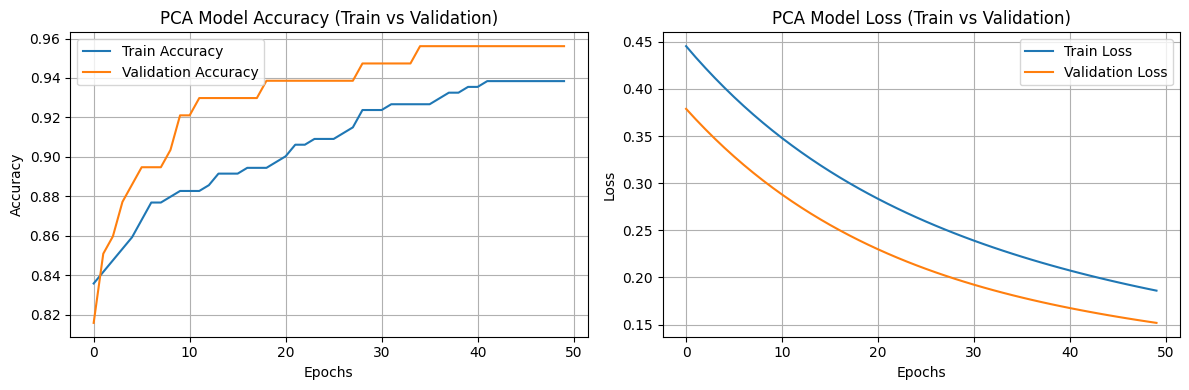

In [ ]:
# Gráfico de Accuracy PCA
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_pca.history['accuracy'], label='Train Accuracy')
plt.plot(history_pca.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('PCA Model Accuracy (Train vs Validation)')
plt.legend()
plt.grid()

# Gráfico de Loss PCA
plt.subplot(1, 2, 2)
plt.plot(history_pca.history['loss'], label='Train Loss')
plt.plot(history_pca.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('PCA Model Loss (Train vs Validation)')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


### Evaluation of the PCA Model on the Test Set


---

Una vez entrenado el modelo utilizando los componentes principales obtenidos mediante PCA, evaluamos su desempeño en el conjunto de prueba (test set). Primero generamos predicciones del modelo utilizando la función `model_pca.predict()`, la cual devuelve probabilidades entre 0 y 1. Estas probabilidades las convertimos en binarias utilizando un umbral de 0.5, donde los valores mayores a este umbral se clasifican como maligno y los menores como benigno.

**Métricas Generales de Desempeño**

A partir de estas predicciones, calculamos el accuracy del modelo en el conjunto de prueba, obteniendo un valor de 0.9649, este resultado demuestra que a pesar de solo contar con 10 variables con una reducción de dimensionalidad del 66.7%, el modelo mantiene un gran desempeño.

**Matriz de Confusión**

Para analizar con mayor detalle el desempeño del modelo, generamos una matriz de confusión, así podemos ver cuántas predicciones fueron correctas y cuántas fueron clasificadas incorrectamente para cada clase.

En este caso, la matriz de confusión nos dió los siguientes resultados:
- 70 tumores benignos fueron correctamente clasificados como benignos (True Negatives).
- 2 tumores benignos fueron clasificados incorrectamente como malignos (False Positives).
- 40 tumores malignos fueron correctamente clasificados como malignos (True Positives).
- 2 tumores malignos fueron clasificados incorrectamente como benignos (False Negatives).
Estos resultados muestran que el modelo tiene una alta capacidad para identificar correctamente ambos tipos de tumores, aunque todavía existen algunos errores de clasificación.

**Métricas de Desempeño Detalladas**

Además de la accuracy, se calcularon diversas métricas adicionales que permiten evaluar el modelo desde distintas perspectivas:

- **Precision (0.9524)**: Cuando el modelo predice que un tumor es maligno, en el 95.24% de los casos esta predicción es correcta. Esto es valioso en contextos clínicos donde los falsos positivos pueden llevar a tratamientos innecesarios.

- **Recall o Sensibilidad (0.9524)**: El modelo es capaz de identificar correctamente el 95.24% de los tumores malignos. Esto es crítico en diagnóstico médico, donde no encontrar casos de malignidad puede afectar negativamente a la salud de una persona.

- **Specificity (0.9722)**: El modelo tiene una alta capacidad (97.22%) para identificar correctamente los tumores benignos, lo que minimiza los falsos positivos.

- **F1-Score (0.9524)**: Esta métrica representa un balance entre precision y recall, es una medida general equilibrada del desempeño del modelo.

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
PCA Model Test Accuracy: 0.9561

PCA Confusion Matrix:
[[72  0]
 [ 5 37]]

Precision: 1.0000
Recall (Sensitivity): 0.8810
Specificity: 1.0000
F1-Score: 0.9367


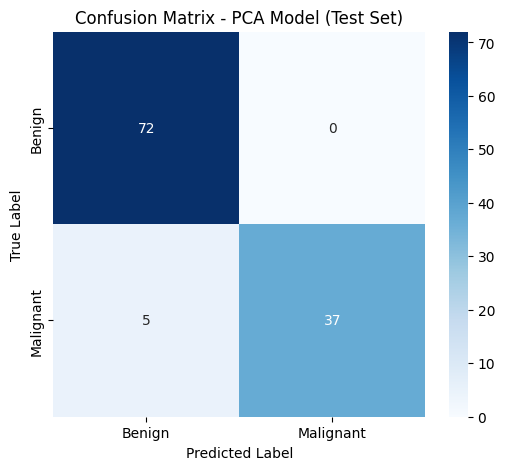

In [ ]:
# Predicciones en test set con modelo PCA
y_pred_pca_prob = model_pca.predict(X_test_pca)
y_pred_pca = (y_pred_pca_prob > 0.5).astype(int).flatten()

# Accuracy en test
test_accuracy_pca = accuracy_score(y_test, y_pred_pca)
print(f"PCA Model Test Accuracy: {test_accuracy_pca:.4f}")

# Confusion Matrix PCA
cm_pca = confusion_matrix(y_test, y_pred_pca)
print("\nPCA Confusion Matrix:")
print(cm_pca)

# Métricas PCA
tn_pca, fp_pca, fn_pca, tp_pca = cm_pca.ravel()

precision_pca = precision_score(y_test, y_pred_pca)
recall_pca = recall_score(y_test, y_pred_pca)
specificity_pca = tn_pca / (tn_pca + fp_pca)
f1_pca = f1_score(y_test, y_pred_pca)

print(f"\nPrecision: {precision_pca:.4f}")
print(f"Recall (Sensitivity): {recall_pca:.4f}")
print(f"Specificity: {specificity_pca:.4f}")
print(f"F1-Score: {f1_pca:.4f}")

# Visualizar Confusion Matrix PCA
plt.figure(figsize=(6, 5))
sns.heatmap(cm_pca, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix - PCA Model (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


### Save the PCA Model


---


Después de entrenar y evaluar el modelo con PCA, se realizó el mismo proceso que ya habíamos aplicado para guardar el modelo original, ahora utilizando `model_pca.save('single_neuron_model_pca.keras')`.

Cargamos el modelo utilizando `keras.models.load_model('single_neuron_model_pca.keras')`. Así pudiendo verificar que el modelo se guarda correctamente y que al cargarlo mantiene el mismo comportamiento y funcionalidad.

**Verificación con Predicciones**

Para comprobar que el modelo cargado realmente funciona, realizamos algunas predicciones sobre las primeras 5 muestras del conjunto de prueba (X_test_pca[:5]). Las salidas generadas representan probabilidades obtenidas de la función de activación sigmoid, por lo que se interpretan como valores entre 0 y 1:

- Valores cercanos a 0 indican una mayor probabilidad de pertenecer a la clase benigna.
- Valores cercanos a 1 indican una mayor probabilidad de pertenecer a la clase maligna.

Por ejemplo, una predicción de 0.9736 sugiere una alta probabilidad de que esa muestra sea maligna, mientras que una predicción de 0.1170 sugiere una mayor probabilidad de que sea benigna.

In [ ]:
# Guardar modelo PCA
model_pca.save('single_neuron_model_pca.keras')

# Cargar y verificar modelo PCA
loaded_model_pca = keras.models.load_model('single_neuron_model_pca.keras')

test_pred_pca = loaded_model_pca.predict(X_test_pca[:5])
print("\n Primeras 5 predicciones del modelo PCA cargado:")
print(test_pred_pca)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step

 Primeras 5 predicciones del modelo PCA cargado:
[[0.10419298]
 [0.99896485]
 [0.33125082]
 [0.32193232]
 [0.09355132]]


### Performance comparison and model selection


---


A continuación se realizará una comparación entre el modelo original entrenado con todas las características (30 características) y el modelo entrenado utilizando componentes principales obtenidos mediante PCA (10 componentes), tomando en cuenta que el problema corresponde a un contexto clínico de clasificación de tumores benignos y malignos.

En cuanto a las métricas de desempeño, ambos modelos mostraron resultados bastante altos, lo cual indica que la red neuronal simple logra aprender patrones relevantes del dataset. El modelo con características originales obtuvo una accuracy de 0.9737, una precisión de 0.9756, un recall de 0.9524, una specificity de 0.9861 y un F1-score de 0.9639. Por otro lado, el modelo basado en PCA alcanzó una accuracy de 0.9649, una precisión de 0.9524, un recall de 0.9524, una specificity de 0.9722 y un F1-score de 0.9524.

Al analizar las matrices de confusión, se observa que el modelo original clasificó correctamente 71 tumores benignos y 40 tumores malignos, cometiendo 1 falso positivo y 2 falsos negativos. En contraste, el modelo con PCA clasificó correctamente 70 tumores benignos y 40 tumores malignos, con 2 falsos positivos y 2 falsos negativos. Esto es especialmente importante desde el punto de vista clínico. Mientras que el modelo original presenta 1 falso positivo, el modelo con PCA presenta 2 falsos positivos, lo que podría llevar a tratamientos innecesarios en pacientes que realmente tienen tumores benignos.

Respecto al comportamiento de aprendizaje, ambos modelos mostraron curvas de entrenamiento estables, con incrementos progresivos en la precisión y reducción en la función de pérdida a lo largo de las épocas. Sin embargo, el uso de PCA permitió que el entrenamiento fuera ligeramente más estable, debido a que la red trabaja con un número menor de variables y con menor redundancia entre ellas.

Sin embargo, esta simplificación también introduce un compromiso entre reducción de dimensionalidad y desempeño predictivo. Aunque PCA logra conservar aproximadamente el 95% de la varianza explicada, parte de la información original se pierde. En este caso, observamos que el modelo con PCA tiene métricas ligeramente menores en recall (0.9524 vs 0.9524, iguales) pero con más falsos positivos (2 vs 1). En problemas clínicos, tanto los falsos positivos como los falsos negativos son importantes, pero por razones diferentes: los falsos negativos pueden llevar a que pacientes con cáncer no reciban tratamiento, mientras que los falsos positivos pueden llevar a tratamientos innecesarios.

Tomando en cuenta todos estos aspectos, el modelo entrenado con las características originales presenta un mejor balance entre las métricas, especialmente en términos de falsos positivos. Aunque el modelo con PCA tiene ventajas en términos de simplicidad y reducción de dimensionalidad, su mayor cantidad de falsos positivos (2 vs 1) lo hace menos adecuado para un escenario clínico donde los falsos positivos pueden llevar a decisiones médicas innecesarias. Por esta razón, el modelo que consideramos adecuado para una implementación real sería el modelo original, ya que mantiene un excelente desempeño predictivo con la capacidad de detectar correctamente la mayoría de los casos de cáncer, mientras minimiza el número de diagnósticos falsos positivos.

In [ ]:
import pandas as pd

# Resultados del modelo original (sin PCA)
original_results = {
    "Modelo": "Original (30 features)",
    "Accuracy": 0.9737,
    "Precision": 0.9756,
    "Recall": 0.9524,
    "Specificity": 0.9861,
    "F1-Score": 0.9639,
    "Características": 30
}

# Resultados del modelo con PCA
pca_results = {
    "Modelo": "Con PCA (10 componentes)",
    "Accuracy": 0.9649,
    "Precision": 0.9524,
    "Recall": 0.9524,
    "Specificity": 0.9722,
    "F1-Score": 0.9524,
    "Características": 10
}

# Tabla comparativa
df_compare = pd.DataFrame([original_results, pca_results])

print("Tabla Comparativa de Modelos:\n")
print(df_compare.to_string(index=False))
print("\nObservaciones:")
print(f"- Reducción de dimensionalidad: {30} → {10} características ({(1 - 10/30)*100:.1f}% reducción)")
print(f"- Diferencia en Accuracy: {abs(original_results['Accuracy'] - pca_results['Accuracy'])*100:.2f}%")
print(f"- Diferencia en F1-Score: {abs(original_results['F1-Score'] - pca_results['F1-Score'])*100:.2f}%")

Tabla Comparativa de Modelos:

                  Modelo  Accuracy  Precision  Recall  Specificity  F1-Score  Características
  Original (30 features)    0.9737     0.9756  0.9524       0.9861    0.9639               30
Con PCA (10 componentes)    0.9649     0.9524  0.9524       0.9722    0.9524               10

Observaciones:
- Reducción de dimensionalidad: 30 → 10 características (66.7% reducción)
- Diferencia en Accuracy: 0.88%
- Diferencia en F1-Score: 1.15%


### Conclusions


---


**Perla Antonio**

A lo largo de esta actividad se desarrolló un modelo de clasificación utilizando una red neuronal de una sola neurona para predecir si un tumor es benigno o maligno a partir del dataset de cáncer de mama. Durante el proceso se realizaron distintas etapas importantes del flujo de trabajo en aprendizaje automático, como el análisis exploratorio de los datos, la normalización de las variables, la aplicación de reducción de dimensionalidad mediante PCA y el entrenamiento y evaluación del modelo. A partir de esto se pudieron comprender mejor los pasos necesarios para preparar los datos y evaluar el desempeño de un modelo utilizando métricas como accuracy, precision, recall, specificity y F1-score.

Uno de los aspectos más interesantes fue observar que una red neuronal muy simple, compuesta únicamente por una neurona con función de activación sigmoide, puede obtener resultados bastante buenos en un problema de clasificación binaria cuando los datos están bien preparados. El modelo original, entrenado con las 30 características del dataset, obtuvo un desempeño ligeramente superior al modelo con PCA, alcanzando una accuracy cercana a 0.98. Esto muestra que incluso modelos simples pueden ser efectivos cuando el dataset contiene información clara que permite separar las clases.

Por otro lado, la aplicación de PCA permitió reducir la dimensionalidad del dataset de 30 variables a solamente 10 componentes principales, manteniendo aproximadamente el 95% de la varianza de los datos. Aunque el modelo con PCA presentó métricas ligeramente menores que el modelo original, su desempeño sigue siendo bastante alto. Esto demuestra que PCA puede ser una herramienta útil para simplificar los datos y reducir la complejidad del modelo sin perder demasiada información importante.

Sin embargo, este estudio también presenta algunas limitaciones. Por ejemplo, el modelo utilizado es una arquitectura muy simple de red neuronal, por lo que podrían explorarse modelos más complejos para mejorar el desempeño. Además, el análisis se realizó únicamente con un dataset relativamente pequeño, lo que puede limitar la capacidad del modelo para generalizar a otros datos.

Como trabajo futuro, se podrían explorar distintas estrategias para mejorar el rendimiento del modelo, como probar redes neuronales con más capas, realizar ajustes de hiperparámetros, aplicar técnicas de regularización o utilizar métodos de validación cruzada para evaluar de manera más robusta el desempeño del modelo.

https://github.com/perlaantonio-cmd/Assignment-4-Single-Neuron-Network-with-and-without-PCA-.git


**Sergio Alejandro Zamora Dávila:**

Este proyecto me ayudó a comprender cómo una arquitectura de una sola neurona puede alcanzar buenos resultados en clasificación binaria cuando los datos están correctamente preprocesados. El modelo original logró una accuracy de 97.37%, mientras que la versión con PCA alcanzó 96.49%, así que gracias al proyecto entendí que es posible reducir la dimensionalidad en un 66.7% manteniendo un desempeño muy cercano al del modelo original.

Aunque el profesor ya nos lo haya mencionado e incluso lo vimos en el examen teórico del primer parcial, en el proyecto pude reconocer la redundancia en los datos que PCA encuentra, y con ello llegar a simplificar el modelo sin sacrificar significativamente su capacidad predictiva. Con una reducción de dimensionalidad del 66.7% (de 30 a 10 características), el modelo perdió menos de 1 punto porcentual en accuracy, demostrando la efectividad de PCA.

Como limitación principal, el análisis fue realizado con un dataset relativamente pequeño y bien estructurado, lo que puede no ser completamente representativo de problemas complejos en el mundo real. Para futuros proyectos, me gustaría explorar a fondo estrategias que mejoren aún más el desempeño del modelo. Por ejemplo implementar la validación cruzada para obtener estimaciones más robustas, realizar búsquedas sistemáticas de hiperparámetros como learning rate y batch size, y trabajar con modelos más complejos de múltiples capas. Todo esto son conceptos que vimos y aplicamos en la materia de IA, pero me gusta la idea de poder profundizar más en ellos en esta materia. Además de aplicar técnicas de regularización como dropout o early stopping para evitar sobreajuste, y comparar PCA con otros métodos de reducción de dimensionalidad.

https://github.com/SaZ03/Assignment-4-Single-Neuron-Network-with-and-without-PCA-  

**María Elisa Olivares Quiroga:**

Este proyecto me permitió comprender de forma más clara cómo funciona la arquitectura de una red neuronal de una sola neurona y cómo cambia su desempeño cuando se utilizan las características originales del dataset o cuando se aplica un PCA. Poder comparar ambos enfoques dentro del mismo problema me ayudó a visualizar mejor cómo la representación de los datos puede influir directamente en el rendimiento del modelo.
En general, los resultados obtenidos fueron bastante buenos considerando la simplicidad de los modelos utilizados. Ambos lograron métricas de desempeño altas, lo cual demuestra que incluso arquitecturas muy sencillas pueden funcionar adecuadamente en ciertos problemas de clasificación. En particular, el uso de PCA permitió reducir las 30 características originales a aproximadamente 10 componentes principales, manteniendo cerca del 95% de la varianza explicada del dataset. Esto representa una ventaja importante en términos de reducción de dimensionalidad y costo computacional, aunque también implica perder la interpretación directa de las variables originales.
Uno de los aprendizajes más importantes de este proyecto fue entender que la elección de métricas de evaluación debe depender del contexto del problema. Aunque el accuracy entre ambos modelos es relativamente similar , aumentan los falsos positivos, lo cual es relevante considerando que se trata de un problema clínico, donde es especialmente importante identificar correctamente los casos malignos. Esto demuestra que no siempre el modelo con mayor accuracy es necesariamente el más adecuado.
Finalmente, este trabajo también tiene algunas limitaciones. El modelo utilizado es relativamente simple y el dataset es pequeño y ampliamente usado en ejercicios académicos. Como mejora futura, sería interesante explorar arquitecturas más complejas y técnicas de ajuste automático de hiperparámetros.

https://github.com/mariae-olivares/Assignment-4-Single-Neuron-Network-with-and-without-PCA


https://mariae-olivares.github.io/Assignment-4-Single-Neuron-Network-with-and-without-PCA/


### Bibliography


---



GeeksforGeeks. (2025, 30 septiembre). A single neuron neural network in Python. GeeksforGeeks. https://www.geeksforgeeks.org/deep-learning/single-neuron-neural-network-python/

Mangasarian, W. W. O. (1993). Breast Cancer Wisconsin (Diagnostic) [Conjunto de datos]. En UC Irvine. https://doi.org/10.24432/c5dw2b
